# Glaucoma Detection Research Pipeline

This notebook implements a lightweight deep learning pipeline for Glaucoma classification (Glaucoma vs. Normal).

### Research Goals:
1.  **Train** a model (MobileNetV3, ResNet, etc.) on the dataset.
2.  **Evaluate** using medical metrics (Sensitivity/Recall).
3.  **Compare** different architectures by changing the `MODEL_NAME` configuration.

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import copy

# Check for GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device selected: {DEVICE}")

🚀 Device selected: cuda


## 1. Configuration (Experiment Setup)
**Crucial:** Change `MODEL_NAME` when you want to run a different experiment (e.g., "ResNet50"). This ensures your result files don't get overwritten.

In [32]:
# --- EXPERIMENT SETTINGS ---
MODEL_NAME = "EfficientNet" # Options: "MobileNetV3", "ResNet18", "EfficientNet"

# UPDATE THESE PATHS to your actual folders!
TRAIN_PATH = "archive/train" 
TEST_PATH = "archive/test"
# ---------------------------

BATCH_SIZE = 16
LEARNING_RATE = 0.001
EPOCHS = 15
SEED = 42
NUM_CLASSES = 2

# Set Reproducibility
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## 2. Data Preparation
Loads data directly from your pre-split 'train' and 'test' folders.

In [33]:
print("📂 Preparing Data...")

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

try:
    # Load datasets from separate folders
    train_dataset = datasets.ImageFolder(root=TRAIN_PATH, transform=data_transforms)
    test_dataset = datasets.ImageFolder(root=TEST_PATH, transform=data_transforms)

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    class_names = train_dataset.classes
    print(f"✅ Data Loaded. Classes: {class_names}")
    print(f"   Training Images: {len(train_dataset)}")
    print(f"   Testing Images:  {len(test_dataset)}")
    
except FileNotFoundError:
    print(f"❌ Error: Could not find dataset folders. Please check TRAIN_PATH and TEST_PATH.")
    print(f"   Looking for Train at: {TRAIN_PATH}")
    print(f"   Looking for Test at: {TEST_PATH}")

📂 Preparing Data...
✅ Data Loaded. Classes: ['Glaucoma', 'Non Glaucoma']
   Training Images: 565
   Testing Images:  140


## 3. Model Selector
This block allows you to switch architectures easily for your comparison study.

In [34]:
print(f"🏗️ Building Model: {MODEL_NAME}...")

if MODEL_NAME == "MobileNetV3":
    model = models.mobilenet_v3_large(weights='DEFAULT')
    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False
    # Modify head
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, NUM_CLASSES)
    optimizer = optim.Adam(model.classifier.parameters(), lr=LEARNING_RATE)

elif MODEL_NAME == "ResNet18":
    model = models.resnet18(weights='DEFAULT')
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, NUM_CLASSES)
    optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)

elif MODEL_NAME == "EfficientNet":
    model = models.efficientnet_b0(weights='DEFAULT')
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
    optimizer = optim.Adam(model.classifier.parameters(), lr=LEARNING_RATE)

model = model.to(DEVICE)
criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler('cuda') # Modern mixed precision

🏗️ Building Model: EfficientNet...


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\VICTUS/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:03<00:00, 5.55MB/s]


## 4. Training Loop

In [35]:
train_acc_history = []
val_acc_history = []
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

print("🔥 Starting Training...")
start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # --- Training Phase ---
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct / total
    train_acc_history.append(epoch_acc)

    # --- Validation Phase ---
    model.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = val_correct / val_total
    val_acc_history.append(val_acc)

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | Val Acc: {val_acc:.4f}")

time_elapsed = time.time() - start_time
print(f"✅ Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
print(f"🏆 Best Validation Accuracy: {best_acc:.4f}")

# Load best weights for final evaluation
model.load_state_dict(best_model_wts)

🔥 Starting Training...
Epoch 1/15 | Loss: 0.4270 | Train Acc: 0.8265 | Val Acc: 0.8429
Epoch 2/15 | Loss: 0.2301 | Train Acc: 0.9327 | Val Acc: 0.9429
Epoch 3/15 | Loss: 0.1547 | Train Acc: 0.9664 | Val Acc: 0.9571
Epoch 4/15 | Loss: 0.1366 | Train Acc: 0.9664 | Val Acc: 0.9500
Epoch 5/15 | Loss: 0.1315 | Train Acc: 0.9664 | Val Acc: 0.9571
Epoch 6/15 | Loss: 0.1184 | Train Acc: 0.9699 | Val Acc: 0.9571
Epoch 7/15 | Loss: 0.1053 | Train Acc: 0.9628 | Val Acc: 0.9571
Epoch 8/15 | Loss: 0.1169 | Train Acc: 0.9593 | Val Acc: 0.9571
Epoch 9/15 | Loss: 0.1059 | Train Acc: 0.9681 | Val Acc: 0.9643
Epoch 10/15 | Loss: 0.0848 | Train Acc: 0.9788 | Val Acc: 0.9714
Epoch 11/15 | Loss: 0.1029 | Train Acc: 0.9664 | Val Acc: 0.9714
Epoch 12/15 | Loss: 0.0792 | Train Acc: 0.9752 | Val Acc: 0.9714
Epoch 13/15 | Loss: 0.0886 | Train Acc: 0.9735 | Val Acc: 0.9643
Epoch 14/15 | Loss: 0.0759 | Train Acc: 0.9894 | Val Acc: 0.9643
Epoch 15/15 | Loss: 0.0846 | Train Acc: 0.9735 | Val Acc: 0.9714
✅ Training 

<All keys matched successfully>

## 5. Evaluation & Saving Results
This section saves the model and plots using the `MODEL_NAME` to prevent overwriting.


📊 Generating Research Metrics...

--- Classification Report ---
              precision    recall  f1-score   support

    Glaucoma       0.96      0.99      0.97        70
Non Glaucoma       0.99      0.96      0.97        70

    accuracy                           0.97       140
   macro avg       0.97      0.97      0.97       140
weighted avg       0.97      0.97      0.97       140



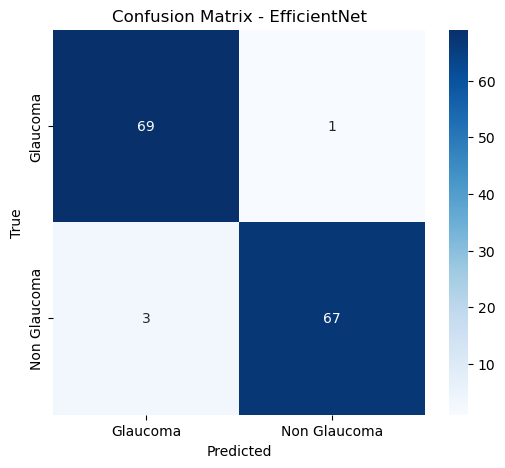

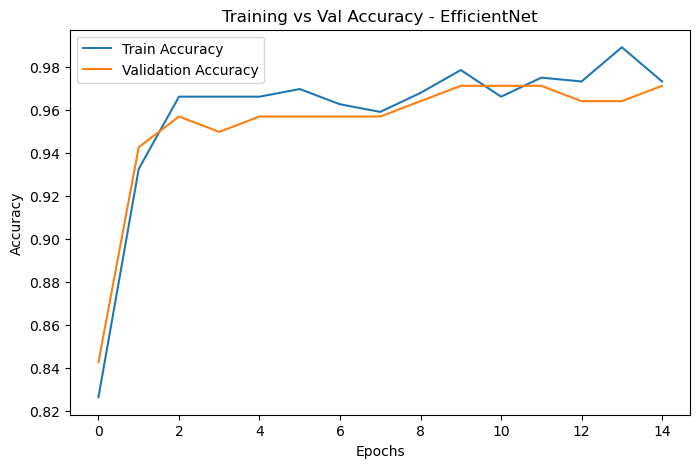

💾 Model saved as 'glaucoma_EfficientNet.pth'
💾 Plots and Report saved with suffix '_EfficientNet'


In [36]:
print("\n📊 Generating Research Metrics...")

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 1. Classification Report
print("\n--- Classification Report ---")
report = classification_report(all_labels, all_preds, target_names=class_names)
print(report)
# Save report to text file
with open(f"report_{MODEL_NAME}.txt", "w") as f:
    f.write(report)

# 2. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - {MODEL_NAME}')
plt.savefig(f'confusion_matrix_{MODEL_NAME}.png') # Auto-Save
plt.show()

# 3. Plot Training Curves
plt.figure(figsize=(8, 5))
plt.plot(train_acc_history, label='Train Accuracy')
plt.plot(val_acc_history, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title(f'Training vs Val Accuracy - {MODEL_NAME}')
plt.savefig(f'training_curves_{MODEL_NAME}.png') # Auto-Save
plt.show()

# 4. Save Model Weights
save_path = f"glaucoma_{MODEL_NAME}.pth"
torch.save(model.state_dict(), save_path)
print(f"💾 Model saved as '{save_path}'")
print(f"💾 Plots and Report saved with suffix '_{MODEL_NAME}'")